# Notebook 2: Activation Probing (Experiment 2)

Reproduces **Figure 3** (per-layer AUROC curves, MLP vs linear comparison)
and key values from the paper body (best-layer AUROC, MLP delta, shuffled baselines).

**Data sources:**
- `results/v4_probes.json` — V4 model-relative probe results (linear + MLP AUROC by layer)
- `results/probes/*.json` — Original-label probe results (for comparison)
- `results/canonical/experiment_2.json` — Shuffled-label baselines and summary statistics
- `activations/*.npz` — Hidden-state activations (optional; needed only to rerun probes from scratch)

In [1]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt

BASE = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..")

## 1. Load V4 probe results

In [2]:
with open(os.path.join(BASE, "results/v4_probes.json")) as f:
    v4_probes = json.load(f)

with open(os.path.join(BASE, "results/canonical/experiment_2.json")) as f:
    canonical_exp2 = json.load(f)

print(f"Models in file: {v4_probes['models']}")
print(f"Label source: {v4_probes['_metadata']['label_source']}")
print(f"CV folds: {v4_probes['_metadata']['n_cv_folds']}")

# Data keys use hyphenated names; display names use spaces
MODEL_KEYS = ["Mistral-7B", "Llama-3.1-8B", "Gemma-2-9B"]
MODEL_DISPLAY = {"Mistral-7B": "Mistral 7B", "Llama-3.1-8B": "Llama 3.1 8B", "Gemma-2-9B": "Gemma 2 9B"}

Models in file: ['Mistral 7B', 'Llama 3.1 8B', 'Gemma 2 9B']
Label source: V4 model-relative labels from phase5_summary_*_v4.json
CV folds: 5


## 2. Figure 3, Panel A: Per-layer K-vs-D AUROC (linear probe)

For each model, plot AUROC at each layer. The peak indicates where the model's
hidden states best separate Known from Declined items.

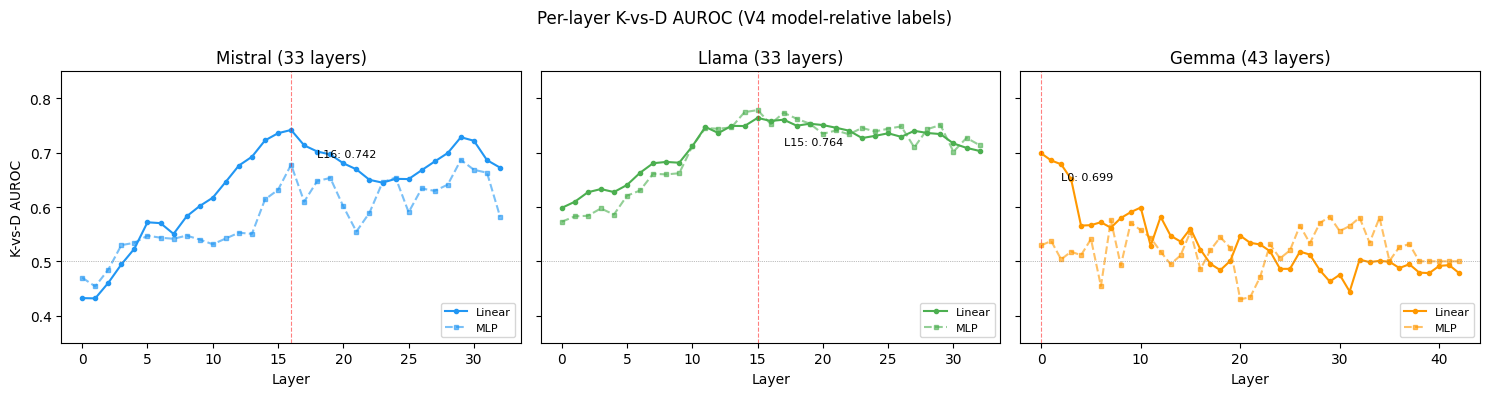

Saved fig3_activation_probing.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
colors = {"Mistral-7B": "#2196F3", "Llama-3.1-8B": "#4CAF50", "Gemma-2-9B": "#FF9800"}

for i, model in enumerate(MODEL_KEYS):
    ax = axes[i]
    data = v4_probes["experiment_2_mlp_vs_linear"][model]

    linear = data["linear_aurocs_by_layer"]
    mlp = data["mlp_aurocs_by_layer"]
    layers = list(range(len(linear)))

    ax.plot(layers, linear, "-o", markersize=3, color=colors[model], label="Linear")
    ax.plot(layers, mlp, "--s", markersize=3, color=colors[model], alpha=0.6, label="MLP")
    ax.axhline(0.5, color="gray", linewidth=0.5, linestyle=":")

    best_layer = data["best_linear_layer"]
    best_auroc = data["best_linear_auroc"]
    ax.axvline(best_layer, color="red", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.annotate(f"L{best_layer}: {best_auroc:.3f}",
                xy=(best_layer, best_auroc), fontsize=8,
                xytext=(best_layer + 2, best_auroc - 0.05))

    short_name = model.split("-")[0]
    ax.set_title(f"{short_name} ({len(linear)} layers)")
    ax.set_xlabel("Layer")
    if i == 0:
        ax.set_ylabel("K-vs-D AUROC")
    ax.legend(fontsize=8, loc="lower right")
    ax.set_ylim(0.35, 0.85)

plt.suptitle("Per-layer K-vs-D AUROC (V4 model-relative labels)", fontsize=12)
plt.tight_layout()
plt.savefig("fig3_activation_probing.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig3_activation_probing.png")

## 3. Key metrics from probing analysis

Extract and verify the values reported in the paper body:
- Best-layer AUROC per model
- MLP vs linear delta
- Spearman rank correlation

In [4]:
print(f"{'Model':<15} {'Best L':>6} {'Lin AUROC':>10} {'MLP AUROC':>10} {'MLP-Lin':>8} {'n_K':>5} {'n_D':>5}")
print("-" * 65)

for model in MODEL_KEYS:
    data = v4_probes["experiment_2_mlp_vs_linear"][model]
    print(f"{model:<15} {data['best_linear_layer']:>6} "
          f"{data['best_linear_auroc']:>10.4f} {data['best_mlp_auroc']:>10.4f} "
          f"{data['mlp_minus_linear']:>8.4f} {data['n_K']:>5} {data['n_D']:>5}")

    # Cross-check against canonical (canonical uses space-separated names)
    can = canonical_exp2["analysis_2a_linear_probing"].get(MODEL_DISPLAY[model], {})

Model           Best L  Lin AUROC  MLP AUROC  MLP-Lin   n_K   n_D
-----------------------------------------------------------------
Mistral-7B          16     0.7420     0.6869  -0.0551   212    77
Llama-3.1-8B        15     0.7642     0.7786   0.0144   216    95
Gemma-2-9B           0     0.6989     0.5824  -0.1165    68    19


## 4. Shuffled-label baselines

The shuffled-label test verifies that probe performance is not an artifact of
the classification procedure. We permute labels and retrain; high z-scores
confirm the probe is detecting real structure.

In [5]:
print(f"{'Model':<15} {'Real AUROC':>10} {'Shuf mean':>10} {'Shuf std':>9} {'z-score':>8} {'p':>6}")
print("-" * 65)

shuffled = canonical_exp2["analysis_2e_shuffled_baselines"]
for model_name, vals in shuffled.items():
    print(f"{model_name:<15} {vals['real_auroc']:>10.4f} "
          f"{vals['shuffled_mean']:>10.4f} {vals['shuffled_std']:>9.4f} "
          f"{vals['z_score']:>8.2f} {vals['p_value']:>6.3f}")

Model           Real AUROC  Shuf mean  Shuf std  z-score      p
-----------------------------------------------------------------
Mistral 7B          0.7511     0.4730    0.0637     4.37  0.000
Llama 3.1 8B        0.7473     0.5055    0.0270     8.96  0.000
Gemma 2 9B          0.6675     0.5135    0.0511     3.01  0.000


## 5. Continuous target analysis (Spearman rho)

Tests whether the probe's decision function correlates with continuous
confidence, not just binary K/D. High Spearman rho = the probe captures
a gradient of knowledge state, not just a binary split.

In [6]:
print(f"{'Model':<15} {'Best Spearman rho':>17} {'Best layer':>10}")
print("-" * 45)
for model in MODEL_KEYS:
    cont = v4_probes["experiment_1_continuous_target"][model]
    print(f"{model:<15} {cont['best_spearman_rho']:>17.4f} {cont['best_layer']:>10}")
    # Full per-layer rho values available in cont['rhos_by_layer']

Model           Best Spearman rho Best layer
---------------------------------------------
Mistral-7B                 0.2286         17
Llama-3.1-8B               0.4238         13
Gemma-2-9B                 0.2796          2


## 6. Comparison with original-label probes

The V4 (model-relative) labels produce different AUROC values from the
original construction-based labels, because each model's K/D/C partition
is different. We load both for comparison.

In [7]:
print(f"{'Model':<15} {'V4 best AUROC':>13} {'Orig best AUROC':>15} {'V4 best L':>9} {'Orig best L':>11}")
print("-" * 70)

for model_key, orig_file in [("Mistral-7B", "mistral7b"),
                              ("Llama-3.1-8B", "llama8b"),
                              ("Gemma-2-9B", "gemma9b")]:
    v4_data = v4_probes["experiment_2_mlp_vs_linear"][model_key]

    with open(os.path.join(BASE, f"results/probes/{orig_file}.json")) as f:
        orig = json.load(f)

    # Original labels: k_vs_d contains per-layer results
    orig_aurocs = [entry["auroc"] for entry in orig["k_vs_d"]]
    orig_best_layer = int(np.argmax(orig_aurocs))
    orig_best_auroc = max(orig_aurocs)

    print(f"{model_key:<15} {v4_data['best_linear_auroc']:>13.4f} "
          f"{orig_best_auroc:>15.4f} {v4_data['best_linear_layer']:>9} {orig_best_layer:>11}")

Model           V4 best AUROC Orig best AUROC V4 best L Orig best L
----------------------------------------------------------------------
Mistral-7B             0.7420          0.6792        16           7
Llama-3.1-8B           0.7642          0.5667        15           6
Gemma-2-9B             0.6989          0.6000         0          20


## 7. Data quality: verify array dimensions match

In [8]:
# Check that activations exist and have expected shapes
# (This cell only runs if activations have been downloaded)
activation_files = {
    "Mistral-7B": ("activations/mistral7b.npz", 33, 4096),
    "Llama-3.1-8B": ("activations/llama8b.npz", 33, 4096),
    "Gemma-2-9B": ("activations/gemma9b.npz", 43, 3584),
}

for model, (path, expected_layers, expected_dim) in activation_files.items():
    full_path = os.path.join(BASE, path)
    if os.path.exists(full_path):
        data = np.load(full_path)
        act = data["activations"]
        print(f"{model}: shape={act.shape}, "
              f"expected=({338}, {expected_layers}, {expected_dim}) "
              f"[{'OK' if act.shape == (338, expected_layers, expected_dim) else 'MISMATCH'}]")
    else:
        print(f"{model}: activations not found at {path} "
              "(download from GitHub release; see activations/README.md)")

Mistral-7B: activations not found at activations/mistral7b.npz (download from GitHub release; see activations/README.md)
Llama-3.1-8B: activations not found at activations/llama8b.npz (download from GitHub release; see activations/README.md)
Gemma-2-9B: activations not found at activations/gemma9b.npz (download from GitHub release; see activations/README.md)
